<center><h1>Zhang_Long_HW2</h1></center>
<br>
USC ID: 8768388438

## Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [ ]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Get the Cycle Power Plant Data Set

In [ ]:
DATA_PATH = Path("../data/CCPP/Folds5x2_pp.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run this notebook from the notebook/ folder "
        "and keep the repository directory structure unchanged."
    )

xls = pd.ExcelFile(DATA_PATH)
print("Sheets:", xls.sheet_names)

df = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
print("Shape:", df.shape)
display(df.head())

Sheets: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5']


Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,"1,024.07",73.17,463.26
1,25.18,62.96,"1,020.04",59.08,444.37
2,5.11,39.4,"1,012.16",92.14,488.56
3,20.86,57.32,"1,010.24",76.64,446.48
4,10.82,37.5,"1,009.23",96.62,473.9


- `AT`: hourly average ambient temperature (°C)
- `V`: hourly average exhaust vacuum
- `AP`: hourly average ambient pressure (mbar)
- `RH`: hourly average relative humidity (%)
- `PE`: net hourly electrical energy output (MW)

### (b) Exploring the data

#### i. rows and columns

In [ ]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")
print("Columns:", list(df.columns))
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']
Missing values:


,missing_count
AT,0
V,0
AP,0
RH,0
PE,0


**Answer.** There are **9,568 rows** and **5 columns**. Each row is one hourly power-plant observation. The columns contain four predictors (`AT`, `V`, `AP`, `RH`) and one response (`PE`).

#### ii. pairwise scatterplots of all the variables

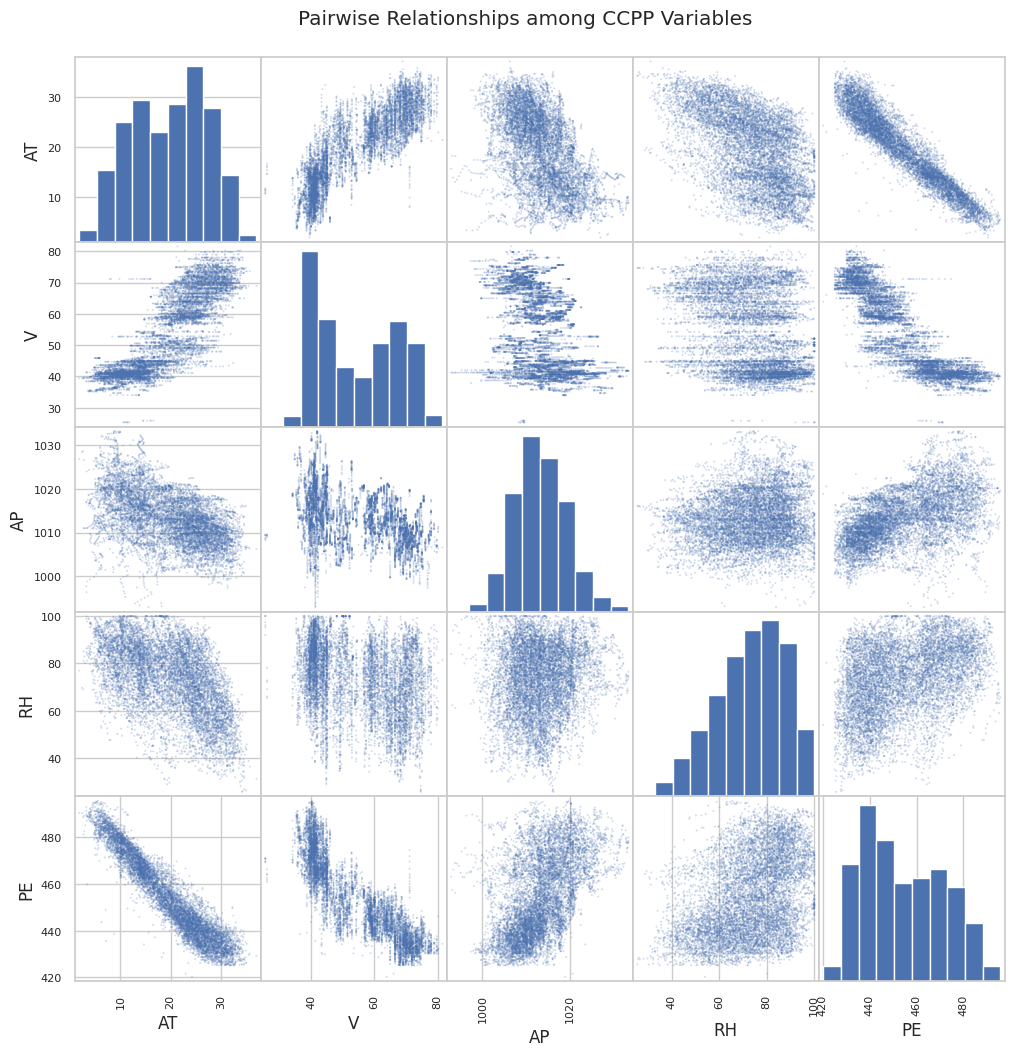

,AT,V,AP,RH,PE
AT,1,0.8441,-0.5075,-0.5425,-0.9481
V,0.8441,1,-0.4135,-0.3122,-0.8698
AP,-0.5075,-0.4135,1,0.0996,0.5184
RH,-0.5425,-0.3122,0.0996,1,0.3898
PE,-0.9481,-0.8698,0.5184,0.3898,1


In [ ]:
from pandas.plotting import scatter_matrix

axes = scatter_matrix(
    df[["AT", "V", "AP", "RH", "PE"]],
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.25,
    s=8
)
plt.suptitle("Pairwise Relationships among CCPP Variables", y=0.92)
plt.show()

corr = df.corr(numeric_only=True)
display(corr.round(4))

**Findings.** `PE` has a very strong negative relationship with `AT` (correlation about **-0.948**) and a strong negative relationship with `V` (about **-0.870**). `AP` and `RH` have weaker positive marginal relationships with `PE` (about **0.518** and **0.390**). `AT` and `V` are also strongly positively correlated (about **0.844**), so the predictors are not independent of one another.

#### iii. mean, median, range, first and third quartiles, and interquartile ranges

In [ ]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
display(summary_table.round(4))

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.6512,20.345,1.81,37.11,35.3,13.51,25.72,12.21
V,54.3058,52.08,25.36,81.56,56.2,41.74,66.54,24.8
AP,"1,013.26","1,012.94",992.89,"1,033.3",40.41,"1,009.1","1,017.26",8.16
RH,73.309,74.975,25.56,100.16,74.6,63.3275,84.83,21.5025
PE,454.365,451.55,420.26,495.76,75.5,439.75,468.43,28.68


The table above reports all requested descriptive statistics. For example, `PE` has mean **454.365 MW**, median **451.55 MW**, range **75.50 MW**, and IQR **28.68 MW**.

### (c) Simple Linear Regression

In [ ]:
predictors = ["AT", "V", "AP", "RH"]
simple_models = {}
simple_rows = []
outlier_rows = []

for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=df).fit()
    simple_models[x] = model
    ci = model.conf_int().loc[x]
    influence = model.get_influence()
    studentized = influence.resid_studentized_internal
    cooks_d = influence.cooks_distance[0]

    simple_rows.append({
        "Predictor": x,
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[x],
        "95% CI Low": ci.iloc[0],
        "95% CI High": ci.iloc[1],
        "p-value": model.pvalues[x],
        "R^2": model.rsquared,
        "Adj. R^2": model.rsquared_adj,
    })
    outlier_rows.append({
        "Predictor": x,
        "|studentized residual| > 3": int((np.abs(studentized) > 3).sum()),
        "Cook's D > 4/n": int((cooks_d > 4/len(df)).sum()),
        "Max Cook's D": cooks_d.max(),
    })

simple_results = pd.DataFrame(simple_rows).set_index("Predictor")
outlier_table = pd.DataFrame(outlier_rows).set_index("Predictor")

display(simple_results)
print()
print("Potential outlier/influence diagnostics:")
display(outlier_table)

,Intercept,Coefficient,95% CI Low,95% CI High,p-value,R^2,Adj. R^2
Predictor,,,,,,,
AT,497.034,-2.17132,-2.18591,-2.15673,0,0.898948,0.898937
V,517.802,-1.16814,-1.18142,-1.15485,0,0.756518,0.756492
AP,"-1,055.26",1.48987,1.44062,1.53912,0,0.268769,0.268692
RH,420.962,0.45565,0.434075,0.477225,0,0.151939,0.151851



Potential outlier/influence diagnostics:


,|studentized residual| > 3,Cook's D > 4/n,Max Cook's D
Predictor,,,
AT,42,416,0.0143248
V,33,423,0.00324295
AP,29,300,0.00815231
RH,2,249,0.00205942


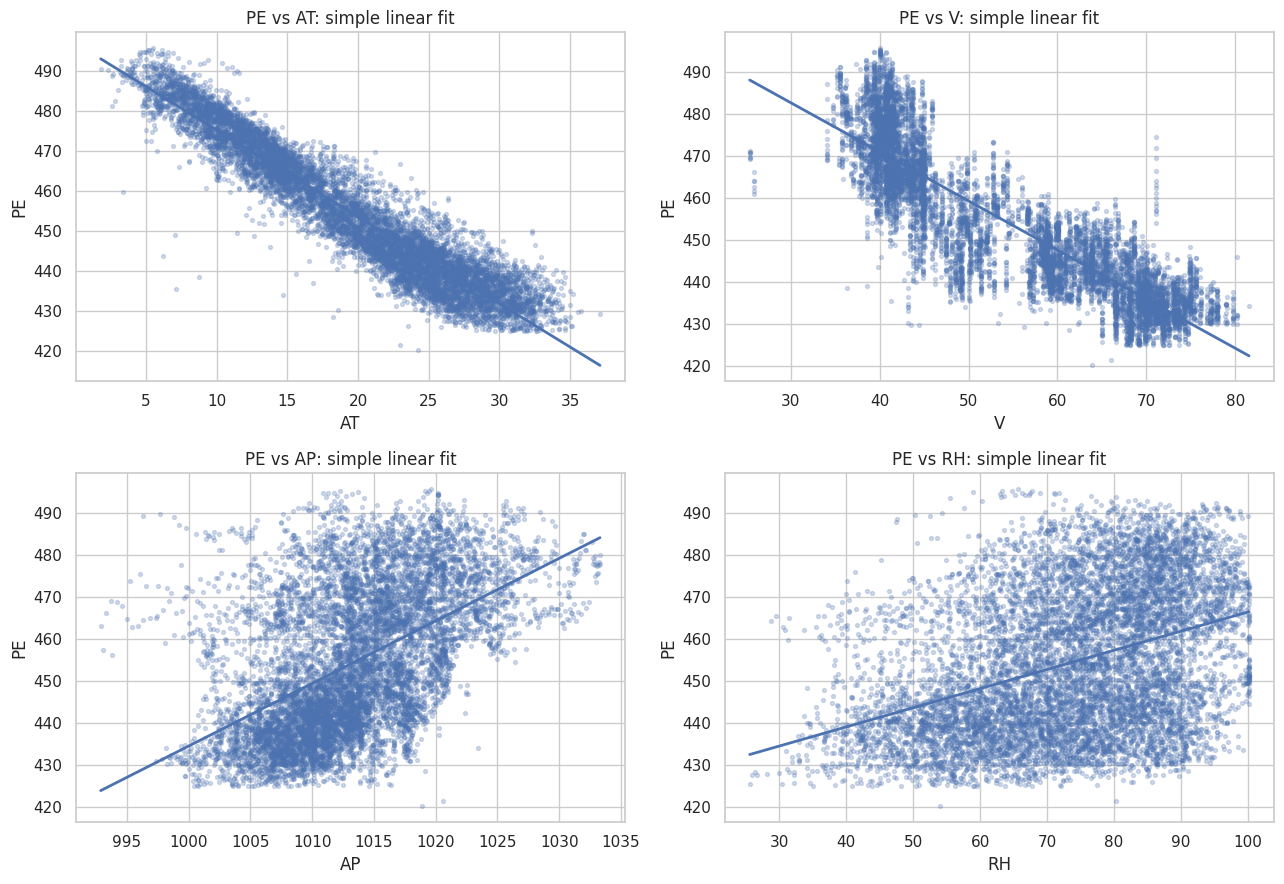

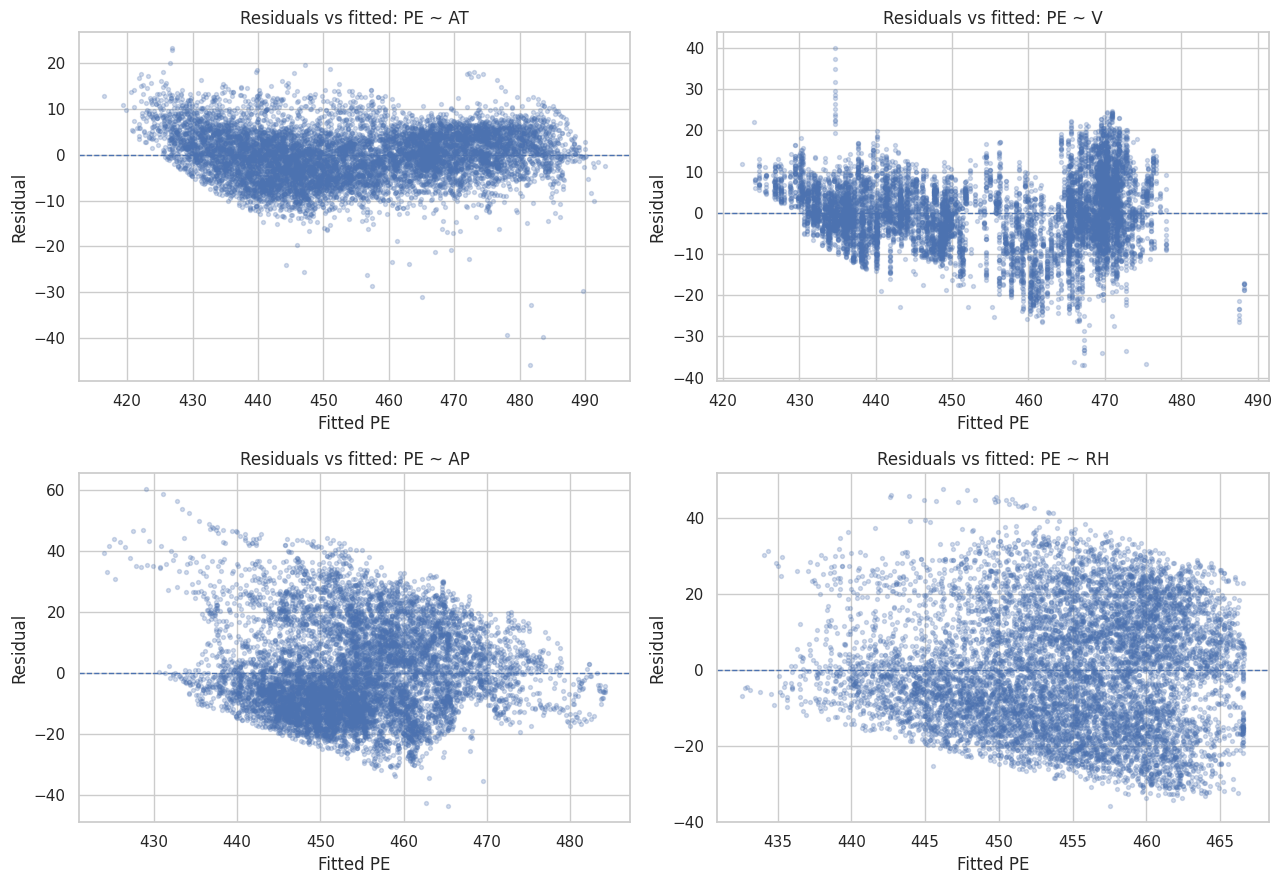

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, x in zip(axes.ravel(), predictors):
    model = simple_models[x]
    grid = np.linspace(df[x].min(), df[x].max(), 200)
    pred = model.params["Intercept"] + model.params[x] * grid
    ax.scatter(df[x], df["PE"], s=8, alpha=0.25)
    ax.plot(grid, pred, linewidth=2)
    ax.set_title(f"PE vs {x}: simple linear fit")
    ax.set_xlabel(x)
    ax.set_ylabel("PE")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, x in zip(axes.ravel(), predictors):
    model = simple_models[x]
    ax.scatter(model.fittedvalues, model.resid, s=8, alpha=0.25)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"Residuals vs fitted: PE ~ {x}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

**Results.** All four simple regressions show a statistically significant marginal association with `PE` (`p < 0.05`; in fact the p-values are extremely small). The estimated slopes are approximately:

- `AT`: **-2.1713**, with $R^2 \approx 0.899$ — strongest simple predictor.
- `V`: **-1.1681**, with $R^2 \approx 0.757$.
- `AP`: **+1.4899**, with $R^2 \approx 0.269$.
- `RH`: **+0.4557**, with $R^2 \approx 0.152$.

The residual plots show that a purely linear model does not capture all structure, especially for `AT` and `V`. There are observations flagged by studentized residuals and Cook's distance. However, I would not automatically remove them: the data set is large, these observations are plausible operating conditions, and there is no evidence that they are data-entry errors.

### (d) Multiple Regression

In [ ]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()

multi_table = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Std. Error": multiple_model.bse,
    "t-stat": multiple_model.tvalues,
    "p-value": multiple_model.pvalues,
    "95% CI Low": multiple_model.conf_int()[0],
    "95% CI High": multiple_model.conf_int()[1],
})
display(multi_table)
print(f"R^2 = {multiple_model.rsquared:.6f}")
print(f"Adjusted R^2 = {multiple_model.rsquared_adj:.6f}")

,Coefficient,Std. Error,t-stat,p-value,95% CI Low,95% CI High
Intercept,454.609,9.74851,46.6337,0,435.5,473.718
AT,-1.97751,0.015289,-129.342,0,-2.00748,-1.94754
V,-0.233916,0.0072821,-32.1221,4.37531e-215,-0.248191,-0.219642
AP,0.0620829,0.00945797,6.56409,5.50711e-11,0.0435433,0.0806226
RH,-0.158054,0.00416826,-37.9185,3.10458e-293,-0.166225,-0.149883


R^2 = 0.928696
Adjusted R^2 = 0.928666


**Answer.** The multiple regression has $R^2 \approx 0.9287$ and adjusted $R^2 \approx 0.9287$. At the 5% significance level, we reject $H_0:\beta_j=0$ for **all four predictors (`AT`, `V`, `AP`, and `RH`)**. Their approximate multiple-regression coefficients are `AT = -1.9775`, `V = -0.2339`, `AP = +0.0621`, and `RH = -0.1581`.

### (e) 1c Compare to 1d

,Simple coefficient,Multiple coefficient
AT,-2.17132,-1.97751
V,-1.16814,-0.233916
AP,1.48987,0.0620829
RH,0.45565,-0.158054


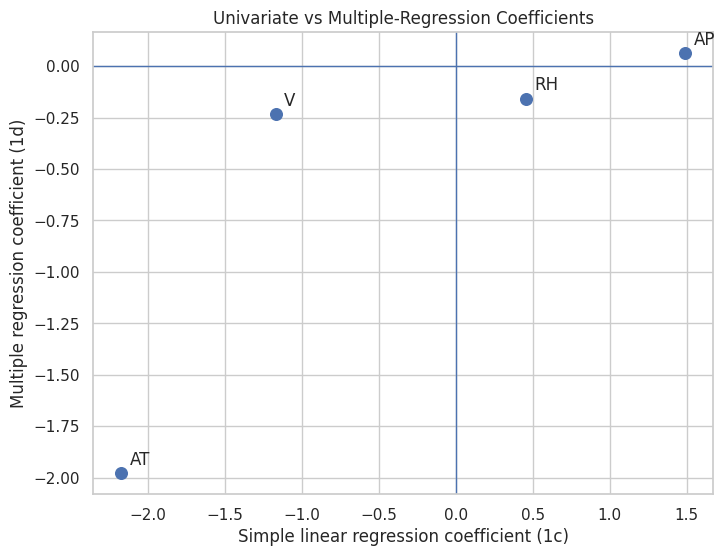

In [ ]:
coef_compare = pd.DataFrame({
    "Simple coefficient": [simple_models[x].params[x] for x in predictors],
    "Multiple coefficient": [multiple_model.params[x] for x in predictors],
}, index=predictors)
display(coef_compare)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coef_compare["Simple coefficient"], coef_compare["Multiple coefficient"], s=70)
for x, row in coef_compare.iterrows():
    ax.annotate(x, (row["Simple coefficient"], row["Multiple coefficient"]), xytext=(6, 6), textcoords="offset points")
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Simple linear regression coefficient (1c)")
ax.set_ylabel("Multiple regression coefficient (1d)")
ax.set_title("Univariate vs Multiple-Regression Coefficients")
plt.show()

**Comparison.** The simple and multiple coefficients differ because the predictors are correlated. `AT` stays strongly negative, but its magnitude decreases after adjustment. `V` also remains negative but becomes much smaller in magnitude. `AP` remains positive but becomes much smaller. Most notably, `RH` changes from a **positive** simple-regression coefficient to a **negative** multiple-regression coefficient. This sign reversal occurs because the simple model does not control for correlated predictors such as `AT` and `V`; the multiple model estimates the association of `RH` with `PE` while holding the other predictors fixed.

### (f) Nonlinear Association

In [ ]:
poly_models = {}
poly_rows = []

for x in predictors:
    model = smf.ols(f"PE ~ {x} + I({x}**2) + I({x}**3)", data=df).fit()
    poly_models[x] = model
    poly_rows.append({
        "Predictor": x,
        "p(linear)": model.pvalues[x],
        "p(quadratic)": model.pvalues[f"I({x} ** 2)"],
        "p(cubic)": model.pvalues[f"I({x} ** 3)"],
        "R^2": model.rsquared,
    })

poly_table = pd.DataFrame(poly_rows).set_index("Predictor")
display(poly_table)

,p(linear),p(quadratic),p(cubic),R^2
Predictor,,,,
AT,7.89815e-07,8.83305e-73,3.65218e-110,0.911883
V,2.52659e-05,0.768497,0.0137349,0.775022
AP,4.50274e-17,3.6667e-17,8.26415e-18,0.274863
RH,0.000377251,9.39543e-06,1.44028e-05,0.153743


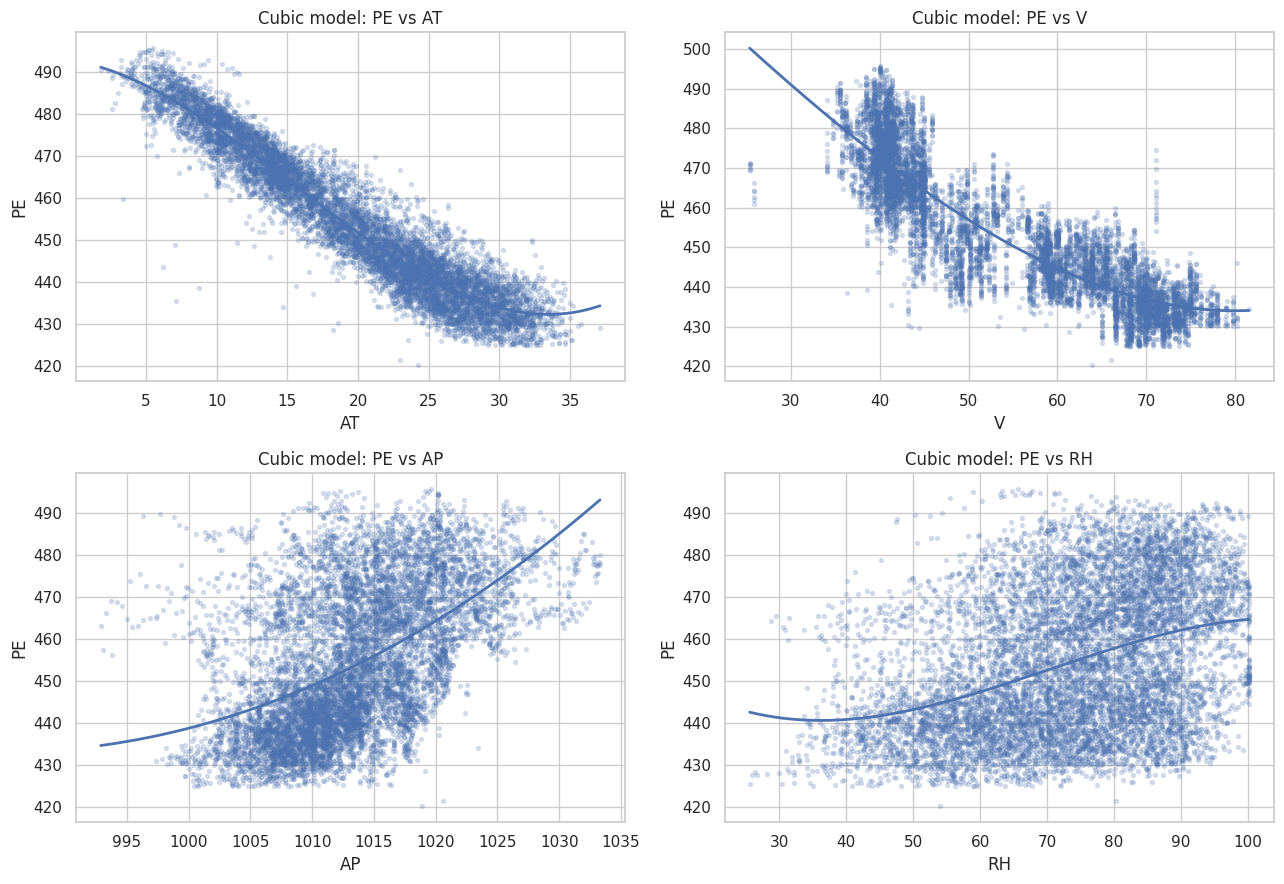

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, x in zip(axes.ravel(), predictors):
    model = poly_models[x]
    grid = pd.DataFrame({x: np.linspace(df[x].min(), df[x].max(), 250)})
    pred = model.predict(grid)
    ax.scatter(df[x], df["PE"], s=8, alpha=0.20)
    ax.plot(grid[x], pred, linewidth=2)
    ax.set_title(f"Cubic model: PE vs {x}")
    ax.set_xlabel(x)
    ax.set_ylabel("PE")
plt.tight_layout()
plt.show()

**Answer.** There is evidence of nonlinear association for the predictors. For `AT`, both the quadratic and cubic terms are highly significant. For `V`, the quadratic term alone is not significant, but the cubic term is significant, which still provides evidence of nonlinearity; because the cubic term is present, the lower-order terms should remain in the hierarchical polynomial model. For `AP` and `RH`, the quadratic and cubic terms are significant. The fitted curves also show departures from straight-line behavior.

### (g) Interactions of Predictors

In [ ]:
interaction_formula = (
    "PE ~ AT + V + AP + RH + "
    "AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
)
interaction_model = smf.ols(interaction_formula, data=df).fit()

interaction_terms = ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"]
interaction_table = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "p-value": interaction_model.pvalues[interaction_terms],
})
interaction_table["Significant at 0.05"] = interaction_table["p-value"] < 0.05
display(interaction_table)
print(f"R^2 = {interaction_model.rsquared:.6f}")
print(f"Adjusted R^2 = {interaction_model.rsquared_adj:.6f}")

,Coefficient,p-value,Significant at 0.05
AT:V,0.0209709,3.33336e-117,True
AT:AP,0.00175905,0.452051,False
AT:RH,-0.00523035,1.21694e-10,True
V:AP,0.00681235,2.87703e-07,True
V:RH,0.000838633,0.0861937,False
AP:RH,-0.0016118,0.0336056,True


R^2 = 0.936306
Adjusted R^2 = 0.936239


**Answer.** At the 5% level, the significant pairwise interactions are **`AT:V`, `AT:RH`, `V:AP`, and `AP:RH`**. `AT:AP` and `V:RH` are not significant in this full interaction model. The interaction model has adjusted $R^2 \approx 0.9362$, higher than the additive multiple-regression model.

### (h) Improvement

In [ ]:
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_STATE
)

baseline_model = smf.ols("PE ~ AT + V + AP + RH", data=train_df).fit()
baseline_train_mse = mean_squared_error(train_df["PE"], baseline_model.predict(train_df))
baseline_test_mse = mean_squared_error(test_df["PE"], baseline_model.predict(test_df))

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print(f"Baseline train MSE: {baseline_train_mse:.6f}")
print(f"Baseline test MSE:  {baseline_test_mse:.6f}")

Training rows: 6697
Test rows: 2871
Baseline train MSE: 20.580840
Baseline test MSE:  21.239857


In [ ]:
main_terms = ["AT", "V", "AP", "RH"]
higher_terms = [
    "I(AT**2)", "I(V**2)", "I(AP**2)", "I(RH**2)",
    "AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"
]

elimination_history = []
while True:
    formula = "PE ~ " + " + ".join(main_terms + higher_terms)
    selected_model = smf.ols(formula, data=train_df).fit()


    p_map = {name.replace(" ", ""): p for name, p in selected_model.pvalues.items()}
    candidates = [
        (term, p_map[term.replace(" ", "")])
        for term in higher_terms
        if p_map[term.replace(" ", "")] > 0.05
    ]

    if not candidates:
        break

    term_to_drop, p_to_drop = max(candidates, key=lambda item: item[1])
    higher_terms.remove(term_to_drop)
    elimination_history.append((term_to_drop, p_to_drop))

print("Removed higher-order terms (in order):")
display(pd.DataFrame(elimination_history, columns=["Removed term", "p-value when removed"]))
print("Final retained higher-order terms:", higher_terms)

selected_train_mse = mean_squared_error(train_df["PE"], selected_model.predict(train_df))
selected_test_mse = mean_squared_error(test_df["PE"], selected_model.predict(test_df))

selected_coef_table = pd.DataFrame({
    "Coefficient": selected_model.params,
    "p-value": selected_model.pvalues,
})
display(selected_coef_table)

mse_h = pd.DataFrame({
    "Train MSE": [baseline_train_mse, selected_train_mse],
    "Test MSE": [baseline_test_mse, selected_test_mse],
}, index=["All predictors (linear)", "Selected interactions + quadratic terms"])
display(mse_h)

Removed higher-order terms (in order):


,Removed term,p-value when removed
0,V:RH,0.867382
1,I(V**2),0.607733
2,V:AP,0.357826


Final retained higher-order terms: ['I(AT**2)', 'I(AP**2)', 'I(RH**2)', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,Coefficient,p-value
Intercept,"-7,568.52",1.02634e-07
AT,-9.6925,2.34516e-05
V,-0.460354,4.32332e-46
AP,15.7203,1.17329e-08
RH,3.72036,0.000135507
I(AT ** 2),0.0195345,5.8538e-16
I(AP ** 2),-0.00764403,1.0732e-08
I(RH ** 2),-0.00194027,2.02248e-12
AT:V,0.00824627,1.54774e-08
AT:AP,0.00697514,0.00150777


,Train MSE,Test MSE
All predictors (linear),20.5808,21.2399
Selected interactions + quadratic terms,17.8908,18.66


**Answer.** With the fixed 70/30 split (`random_state=42`), the additive linear model has train MSE about **20.581** and test MSE about **21.240**. Starting from all pairwise interactions and all quadratic terms, backward elimination removes insignificant higher-order terms while retaining all main effects for hierarchy. The final selected model has train MSE about **17.891** and test MSE about **18.660**.

### (i) KNN

In [ ]:
features = ["AT", "V", "AP", "RH"]
X_train = train_df[features].to_numpy()
X_test = test_df[features].to_numpy()
y_train = train_df["PE"].to_numpy()
y_test = test_df["PE"].to_numpy()
ks = np.arange(1, 101)


def knn_error_curves(Xtr, Xte, ytr, yte, max_k=100):
    """Efficiently compute KNN-regression train/test MSE for k=1,...,max_k."""
    nn = NearestNeighbors(n_neighbors=max_k, algorithm="kd_tree")
    nn.fit(Xtr)

    train_idx = nn.kneighbors(Xtr, return_distance=False)
    test_idx = nn.kneighbors(Xte, return_distance=False)

    divisors = np.arange(1, max_k + 1)
    train_preds = np.cumsum(ytr[train_idx], axis=1) / divisors
    test_preds = np.cumsum(ytr[test_idx], axis=1) / divisors

    train_mse = ((train_preds - ytr[:, None]) ** 2).mean(axis=0)
    test_mse = ((test_preds - yte[:, None]) ** 2).mean(axis=0)
    return train_mse, test_mse


raw_train_mse, raw_test_mse = knn_error_curves(X_train, X_test, y_train, y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
norm_train_mse, norm_test_mse = knn_error_curves(
    X_train_scaled, X_test_scaled, y_train, y_test
)

best_raw_idx = int(np.argmin(raw_test_mse))
best_norm_idx = int(np.argmin(norm_test_mse))
best_raw_k = int(ks[best_raw_idx])
best_norm_k = int(ks[best_norm_idx])

knn_summary = pd.DataFrame({
    "Best k": [best_raw_k, best_norm_k],
    "Train MSE at best k": [raw_train_mse[best_raw_idx], norm_train_mse[best_norm_idx]],
    "Test MSE at best k": [raw_test_mse[best_raw_idx], norm_test_mse[best_norm_idx]],
}, index=["Raw features", "Normalized features"])
display(knn_summary)

,Best k,Train MSE at best k,Test MSE at best k
Raw features,5,10.6008,15.7268
Normalized features,4,8.59143,14.3057


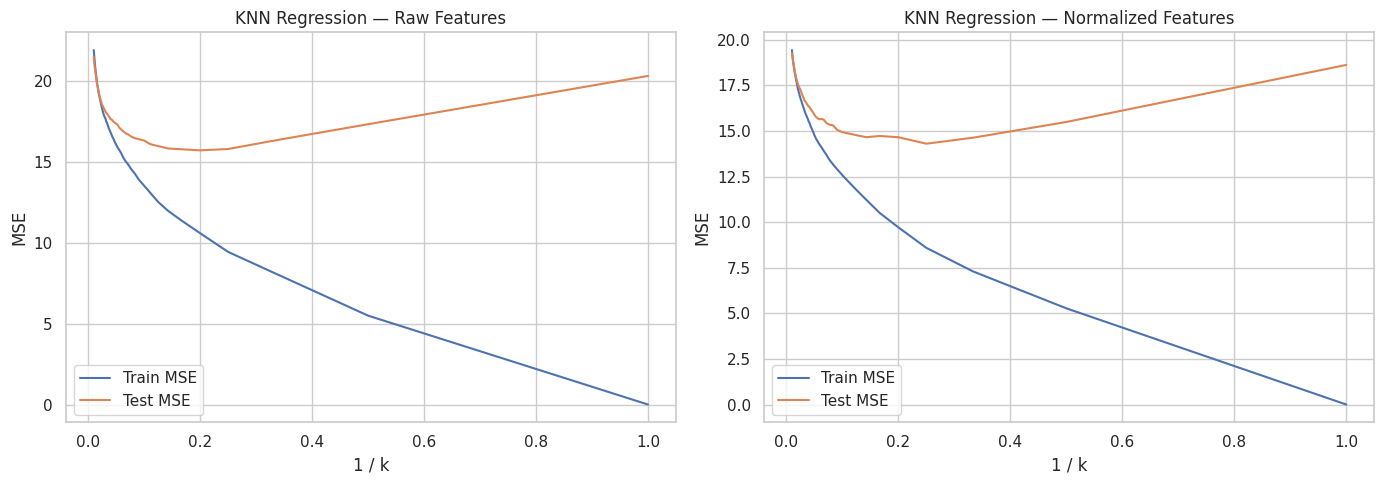

In [ ]:
inv_k = 1 / ks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inv_k, raw_train_mse, label="Train MSE")
axes[0].plot(inv_k, raw_test_mse, label="Test MSE")
axes[0].set_title("KNN Regression — Raw Features")
axes[0].set_xlabel("1 / k")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(inv_k, norm_train_mse, label="Train MSE")
axes[1].plot(inv_k, norm_test_mse, label="Test MSE")
axes[1].set_title("KNN Regression — Normalized Features")
axes[1].set_xlabel("1 / k")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer.** For raw features, the best test performance occurs at approximately **k = 5**, with test MSE about **15.727**. For standardized features, the best value is approximately **k = 4**, with test MSE about **14.306**. Normalization improves KNN because Euclidean distance is otherwise dominated by predictors with larger numerical scales (especially `AP`).

### (j) Compare KNN and Linear

In [ ]:
comparison = pd.DataFrame({
    "Train MSE": [
        baseline_train_mse,
        selected_train_mse,
        raw_train_mse[best_raw_idx],
        norm_train_mse[best_norm_idx],
    ],
    "Test MSE": [
        baseline_test_mse,
        selected_test_mse,
        raw_test_mse[best_raw_idx],
        norm_test_mse[best_norm_idx],
    ],
}, index=[
    "Additive linear regression",
    "Selected interaction/quadratic regression",
    f"KNN raw (k={best_raw_k})",
    f"KNN normalized (k={best_norm_k})",
])
display(comparison)

improvement_pct = 100 * (selected_test_mse - norm_test_mse[best_norm_idx]) / selected_test_mse
print(f"Normalized KNN reduces test MSE by {improvement_pct:.2f}% relative to the best linear-family model above.")

,Train MSE,Test MSE
Additive linear regression,20.5808,21.2399
Selected interaction/quadratic regression,17.8908,18.66
KNN raw (k=5),10.6008,15.7268
KNN normalized (k=4),8.59143,14.3057


Normalized KNN reduces test MSE by 23.34% relative to the best linear-family model above.


**Analysis.** The selected regression model with interactions and quadratic terms is the best linear-family model here (test MSE about **18.660**), but normalized KNN performs better (test MSE about **14.306** at `k = 4`). This is roughly a **23% reduction in test MSE**. The result suggests that the response surface contains local/nonlinear structure that a relatively low-order global regression does not fully capture. KNN benefits strongly from normalization. The trade-off is interpretability: the regression coefficients directly describe effects and interactions, while KNN gives better predictive accuracy here but is less interpretable.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A **more flexible** statistical learning method would generally perform better. With very large $n$ and small $p$, there is enough data to estimate a flexible relationship without excessive variance, so the method can reduce bias and capture more complex structure.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A **less flexible** method would generally perform better. When $p$ is very large relative to $n$, a flexible method has high variance and can easily overfit the small training sample.

### (c) The relationship between the predictors and response is highly non-linear.

A **more flexible** method would generally perform better because it can adapt to the highly nonlinear relationship. A rigid model such as a simple linear model would have high bias.

### (d) The variance of the error terms, i.e. $\sigma^2 = \mathrm{Var}(\epsilon)$, is extremely high.

A **less flexible** method would generally perform better. When irreducible error is very high, a flexible method is more likely to fit noise rather than signal, increasing variance and test error.

## 3. ISLR: 2.4.7

### Training data

In [ ]:
islr_knn = pd.DataFrame({
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
})
display(islr_knn)

,Obs,X1,X2,X3,Y
0,1,0,3,0,Red
1,2,2,0,0,Red
2,3,0,1,3,Red
3,4,0,1,2,Green
4,5,-1,0,1,Green
5,6,1,1,1,Red


### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [ ]:
test_point = np.array([0, 0, 0])
X_islr = islr_knn[["X1", "X2", "X3"]].to_numpy()
islr_knn["Distance to (0,0,0)"] = np.sqrt(((X_islr - test_point) ** 2).sum(axis=1))
display(islr_knn[["Obs", "X1", "X2", "X3", "Y", "Distance to (0,0,0)"]])

,Obs,X1,X2,X3,Y,"Distance to (0,0,0)"
0,1,0,3,0,Red,3
1,2,2,0,0,Red,2
2,3,0,1,3,Red,3.16228
3,4,0,1,2,Green,2.23607
4,5,-1,0,1,Green,1.41421
5,6,1,1,1,Red,1.73205


The distances are $3$, $2$, $\sqrt{10}\approx3.162$, $\sqrt{5}\approx2.236$, $\sqrt{2}\approx1.414$, and $\sqrt{3}\approx1.732$ for observations 1 through 6, respectively.

### (b) What is our prediction with K = 1? Why?

The prediction is **Green**. The nearest observation is observation 5, whose response is Green.

### (c) What is our prediction with K = 3? Why?

The prediction is **Red**. The three nearest observations are 5 (Green), 6 (Red), and 2 (Red), so the majority class is Red, 2-to-1.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect a **small K**. Small K makes KNN more flexible and allows a highly nonlinear decision boundary. Large K averages over a broader neighborhood, producing a smoother and less flexible boundary.

## References

- UCI Machine Learning Repository, Combined Cycle Power Plant Data Set: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant
- James, Witten, Hastie, Tibshirani, *An Introduction to Statistical Learning*.
- Statsmodels OLS documentation: https://www.statsmodels.org/stable/regression.html
- ChatGPT
- scikit-learn nearest neighbors documentation: https://scikit-learn.org/stable/modules/neighbors.html
- scikit-learn preprocessing / StandardScaler documentation: https://scikit-learn.org/stable/modules/preprocessing.html